In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.data.dataset import FacesDataset
from src.utils.augmentations import get_train_transform, get_test_transform
from src.training.train_gan import train_gan_full,build_gan_models, train_gan_with_epoch_callback
from src.evaluation.gan_generate import (
    generate_samples, show_images, save_samples, compute_fid, compute_is
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32

# Load data
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

# Add image paths
for df in [train_df, test_df]:
    df["image_path"] = df["id"].apply(
        lambda x: f"../data/processed_64/face-{int(x)}.png"
    )

# Create datasets and dataloaders
train_loader = DataLoader(
    FacesDataset(train_df, transform=get_train_transform(64)), 
    batch_size=batch_size, shuffle=True
)
test_loader = DataLoader(
    FacesDataset(test_df, transform=get_test_transform(64)), 
    batch_size=batch_size, shuffle=False
)

# Configuration
base_config = {
    "latent_dim": 128,
    "g_channels": [512, 256, 128, 64],
    "d_channels": [64, 128, 256, 512],
    "use_batchnorm": True,
    "activation": "relu",
    "lr": 2e-4
}

/tmp/ipykernel_128010/1871417508.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["image_path"] = df["id"].apply(


In [4]:
# Helper function for evaluation
def evaluate_and_save(G, device, latent_dim, save_path, test_loader=None):
    """Evaluate GAN and save generated samples"""
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    fid_score = compute_fid(G, test_loader or train_loader, device, latent_dim=latent_dim)
    is_score = compute_is(G, device, latent_dim=latent_dim)
    save_samples(G, device, save_path, latent_dim=latent_dim)
    
    return fid_score, is_score

# Train base model
print("Training base GAN model...")
G, D, G_losses, D_losses = train_gan_full(
    config=base_config,
    device=device,
    train_loader=train_loader,
    epochs=20
)

# Evaluate
print("Evaluating model...")
fid_score, is_score = evaluate_and_save(
    G, device, 
    base_config["latent_dim"],
    "../outputs/gan_images/base_model.png",
    test_loader
)
print(f"Base Model - FID: {fid_score:.2f}, IS: {is_score:.2f}")

Training base GAN model...


Epoch [1/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [2/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [3/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [4/20]:   0%|          | 0/141 [00:00<?, ?it/s]

...

Epoch [19/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [20/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Evaluating model...


/home/crisp/Projects/Gen AI - A1/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Base Model - FID: 169.88, IS: 1.63


In [9]:
# Ablation Study - Run multiple experiments with train/eval metrics
experiments = [
    {"name": "base", "latent_dim": 128},
    {"name": "latent_64", "latent_dim": 64},
    {"name": "latent_256", "latent_dim": 256},
    {"name": "no_batchnorm", "use_batchnorm": False},
    {"name": "low_lr", "lr": 1e-4},
]

results = []
for exp in experiments:
    print(f"\n{'='*50}")
    print(f"Running: {exp['name']}")
    print('='*50)
    
    config = {**base_config, **exp}
    
    # Determine changed parameters for this experiment
    changed_params = []
    if "latent_dim" in exp:
        changed_params.append(f"latent_dim={exp['latent_dim']}")
    if "use_batchnorm" in exp:
        changed_params.append(f"batchnorm={exp['use_batchnorm']}")
    if "lr" in exp:
        changed_params.append(f"lr={exp['lr']}")
    changed_text = ", ".join(changed_params) if changed_params else "None"
    
    try:
        G, D, G_losses, D_losses = train_gan_full(
            config=config,
            device=device,
            train_loader=train_loader,
            epochs=20
        )
        
        # Save image path
        image_path = f"../outputs/gan_images/{exp['name']}.png"
        
        # Compute metrics on test set (eval)
        fid_eval, is_eval = evaluate_and_save(G, device, config["latent_dim"], image_path, test_loader)
        
        # Compute metrics on train set
        fid_train = compute_fid(G, train_loader, device, latent_dim=config["latent_dim"])
        is_train = compute_is(G, device, latent_dim=config["latent_dim"])
        
        # Average loss
        avg_loss = (G_losses[-1] + D_losses[-1]) / 2
        
        print(f"✓ {exp['name']} - Train FID: {fid_train:.2f}, Eval FID: {fid_eval:.2f}, Train IS: {is_train:.2f}, Eval IS: {is_eval:.2f}")
        
        results.append({
            "experiment": exp['name'],
            "image_path": image_path,
            "loss": avg_loss,
            "train_fid": fid_train,
            "eval_fid": fid_eval,
            "train_is": is_train,
            "eval_is": is_eval,
            "changed_params": changed_text,
            "latent_dim": config["latent_dim"],
            "batchnorm": config["use_batchnorm"],
            "lr": config["lr"],
            "G_loss": G_losses[-1],
            "D_loss": D_losses[-1]
        })
    except Exception as e:
        print(f"✗ Failed: {exp['name']} → {e}")

# Display results
if results:
    ablation_table = pd.DataFrame(results)
    print("\n" + "="*50)
    print("ABLATION STUDY RESULTS")
    print("="*50)
    print(ablation_table[["experiment", "loss", "train_fid", "eval_fid", "train_is", "eval_is", "changed_params"]].to_string(index=False))


Running: base


Epoch [1/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [2/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [3/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [4/20]:   0%|          | 0/141 [00:00<?, ?it/s]

...

Epoch [17/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [18/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [19/20]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [20/20]:   0%|          | 0/141 [00:00<?, ?it/s]

✓ low_lr - Train FID: 170.31, Eval FID: 213.64, Train IS: 1.73, Eval IS: 1.78

ABLATION STUDY RESULTS
  experiment     loss  train_fid   eval_fid  train_is  eval_is  changed_params
        base 1.656773 126.645348 166.273056  1.573785 1.607169  latent_dim=128
   latent_64 2.116399 124.150848 160.836853  1.566645 1.573863   latent_dim=64
  latent_256 2.765485 128.052780 164.771179  1.609587 1.652245  latent_dim=256
no_batchnorm 1.427494 188.346420 233.350098  1.627358 1.659510 batchnorm=False
      low_lr 1.205039 170.310562 213.641754  1.729157 1.780467       lr=0.0001


In [12]:
# Ablation Cards Visualization Function
def plot_ablation_cards(df, figsize=(24, 8), title_fontsize=22, metrics_fontsize=15):
    """Plot ablation cards with experiment names, images, metrics, and changes."""
    import os

    n = len(df)
    fig, axes = plt.subplots(2, n, figsize=figsize)

    if n == 1:
        axes = [[axes[0]], [axes[1]]]

    for i, row in df.reset_index(drop=True).iterrows():
        # Top row: experiment name + image
        axes[0, i].set_title(row["experiment"], fontsize=title_fontsize, pad=12, fontweight="bold")
        img_path = str(row["image_path"])

        try:
            if not os.path.exists(img_path):
                raise FileNotFoundError(img_path)
            img = plt.imread(img_path)
            axes[0, i].imshow(img)
        except Exception:
            axes[0, i].text(0.5, 0.5, "Image not found", ha="center", va="center", fontsize=metrics_fontsize)
        axes[0, i].axis("off")

        # Bottom row: metrics + changed params
        axes[1, i].axis("off")
        text = (
            f"Loss: {row['loss']:.4f}\n\n"
            f"Train FID: {row['train_fid']:.4f}\n\n"
            f"Train IS: {row['train_is']:.4f}\n\n"
            f"Eval FID: {row['eval_fid']:.4f}\n\n"
            f"Eval IS: {row['eval_is']:.4f}\n\n"
            f"Changes: {row['changed_params']}"
        )
        axes[1, i].text(
            0.5,
            0.5,
            text,
            ha="center",
            va="center",
            fontsize=metrics_fontsize,
            linespacing=1.6,
        )

    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.tight_layout()
    plt.show()

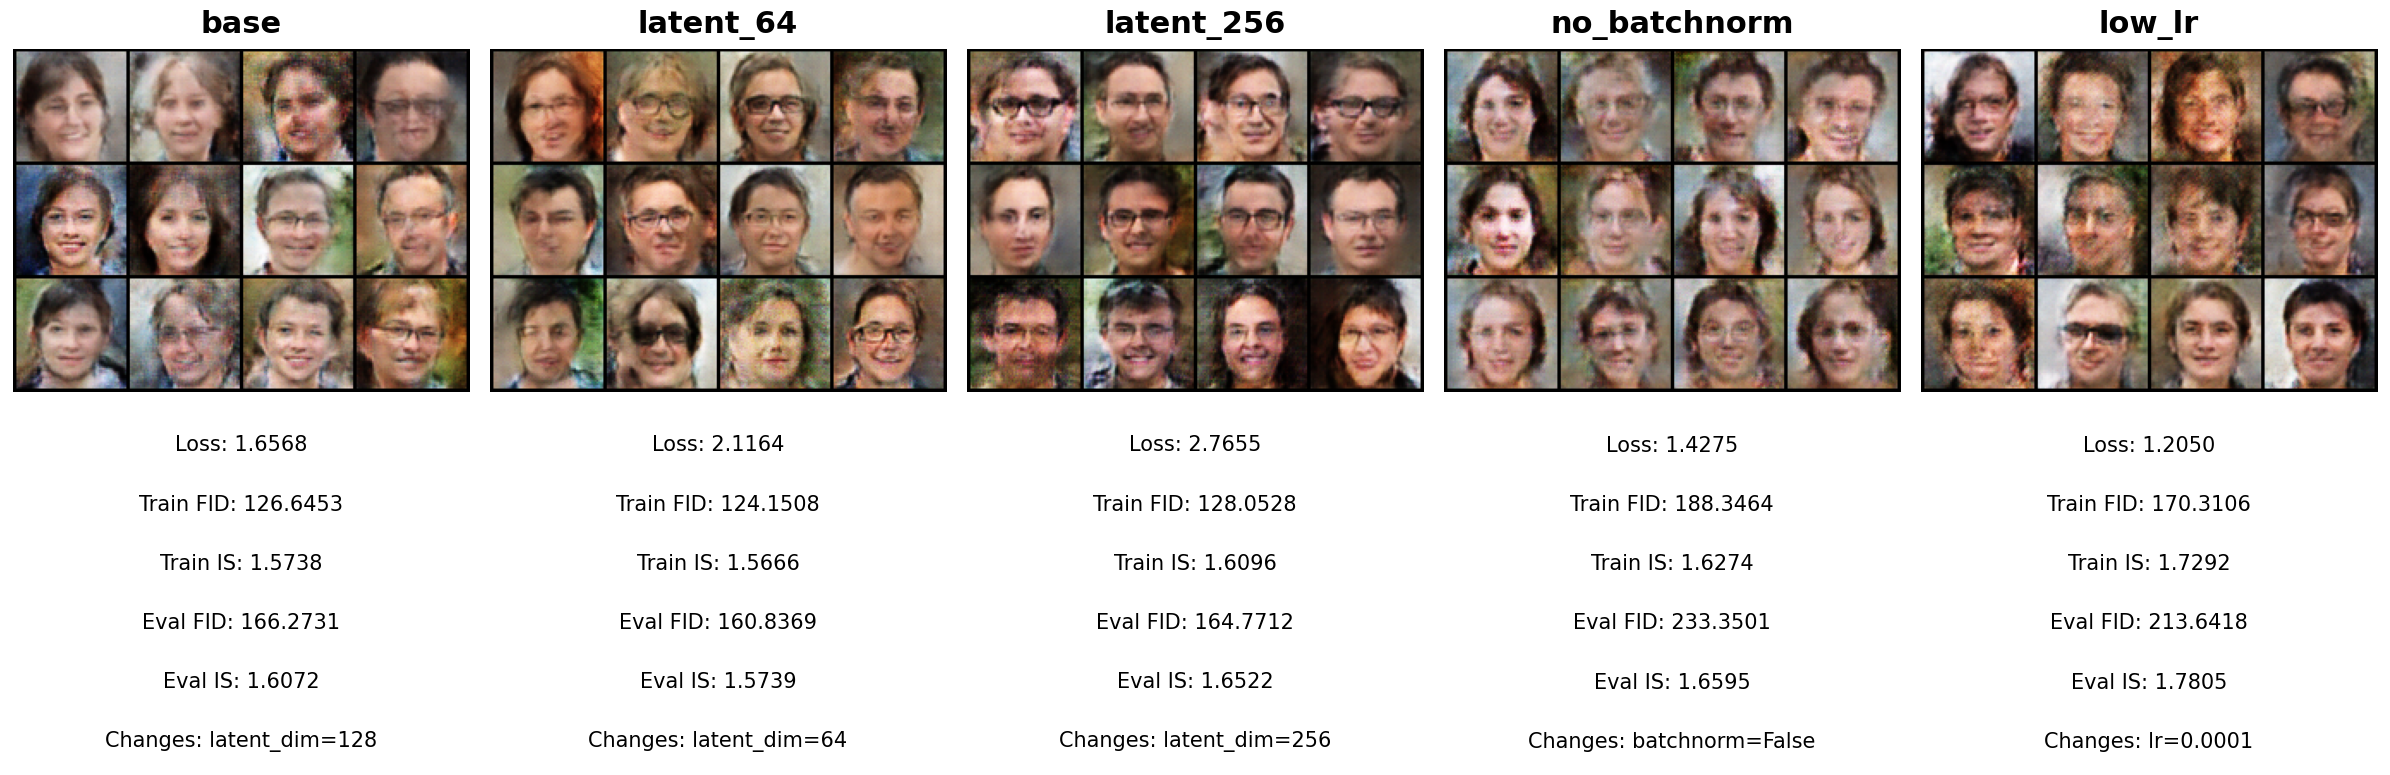

In [13]:
# Display Ablation Cards
plot_ablation_cards(ablation_table)

In [ ]:
# Train final model with checkpoints, image generation, and metrics evaluation
print("Training final model (300 epochs with checkpoints and evaluation)...")

final_config = base_config.copy()
final_config["latent_dim"] = 64
EPOCHS = 300
CHECKPOINT_INTERVAL = 20  # Save every 20 epochs
EVAL_INTERVAL = 5  # Evaluate every 5 epochs

checkpoint_dir = "../models/gan_checkpoints"
image_checkpoint_dir = "../outputs/gan_checkpoints"

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(image_checkpoint_dir, exist_ok=True)

metrics_history = {
    "epoch": [],
    "FID": [],
    "G_loss": [],
    "D_loss": [],
}

# Create generator and discriminator for final training
G_final, D_final = build_gan_models(final_config, device)

def checkpoint_callback(epoch, generator, discriminator, g_loss, d_loss):
    """Called after each epoch to save checkpoints and evaluate."""
    epoch_num = epoch + 1
    # Save checkpoint every 20 epochs
    if epoch_num % CHECKPOINT_INTERVAL == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f"gan_epoch_{epoch_num}.pth")
        torch.save(
            {
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "epoch": epoch_num,
                "config": final_config,
            },
            checkpoint_path,
        )
        print(f"✓ Checkpoint saved: epoch {epoch_num}")

        # Generate images from this checkpoint
        sample_path = os.path.join(image_checkpoint_dir, f"gan_epoch_{epoch_num}.png")
        save_samples(generator, device, sample_path, latent_dim=final_config["latent_dim"])
        print(f"✓ Generated images saved: {sample_path}")

    # Evaluate every 5 epochs
    if epoch_num % EVAL_INTERVAL == 0:
        print(f"\nEvaluating at epoch {epoch_num}...")
        fid_score = compute_fid(
            generator,
            test_loader,
            device,
            latent_dim=final_config["latent_dim"],
        )

        metrics_history["epoch"].append(epoch_num)
        metrics_history["FID"].append(fid_score)
        metrics_history["G_loss"].append(g_loss)
        metrics_history["D_loss"].append(d_loss)

        print(f"Epoch {epoch_num} - FID: {fid_score:.2f}\n")

G_losses_final, D_losses_final = train_gan_with_epoch_callback(
    generator=G_final,
    discriminator=D_final,
    dataloader=train_loader,
    device=device,
    epochs=EPOCHS,
    latent_dim=final_config["latent_dim"],
    lr=final_config["lr"],
    epoch_callback=checkpoint_callback,
)

# Save final checkpoint in the same format as periodic checkpoints
final_ckpt_model_path = os.path.join(checkpoint_dir, "gan_final.pth")
final_ckpt_output_path = "../outputs/final_generator.pth"

final_payload = {
    "generator_state_dict": G_final.state_dict(),
    "discriminator_state_dict": D_final.state_dict(),
    "epoch": EPOCHS,
    "config": final_config,
}

torch.save(final_payload, final_ckpt_model_path)
torch.save(final_payload, final_ckpt_output_path)

print(f"✓ Final checkpoint saved to {final_ckpt_model_path}")
print(f"✓ Final checkpoint saved to {final_ckpt_output_path}")
print("\n✓ Training completed!")

Training final model (300 epochs with checkpoints and evaluation)...


Epoch [1/300]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [2/300]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [3/300]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [4/300]:   0%|          | 0/141 [00:00<?, ?it/s]

...

Epoch [178/300]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [179/300]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch [180/300]:   0%|          | 0/141 [00:00<?, ?it/s]

✓ Checkpoint saved: epoch 180
✓ Generated images saved: ../outputs/gan_checkpoints/gan_epoch_180.png

Evaluating at epoch 180...


OutOfMemoryError: CUDA out of memory. Tried to allocate 170.00 MiB. GPU 0 has a total capacity of 5.65 GiB of which 58.06 MiB is free. Including non-PyTorch memory, this process has 4.90 GiB memory in use. Of the allocated memory 4.47 GiB is allocated by PyTorch, and 254.96 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

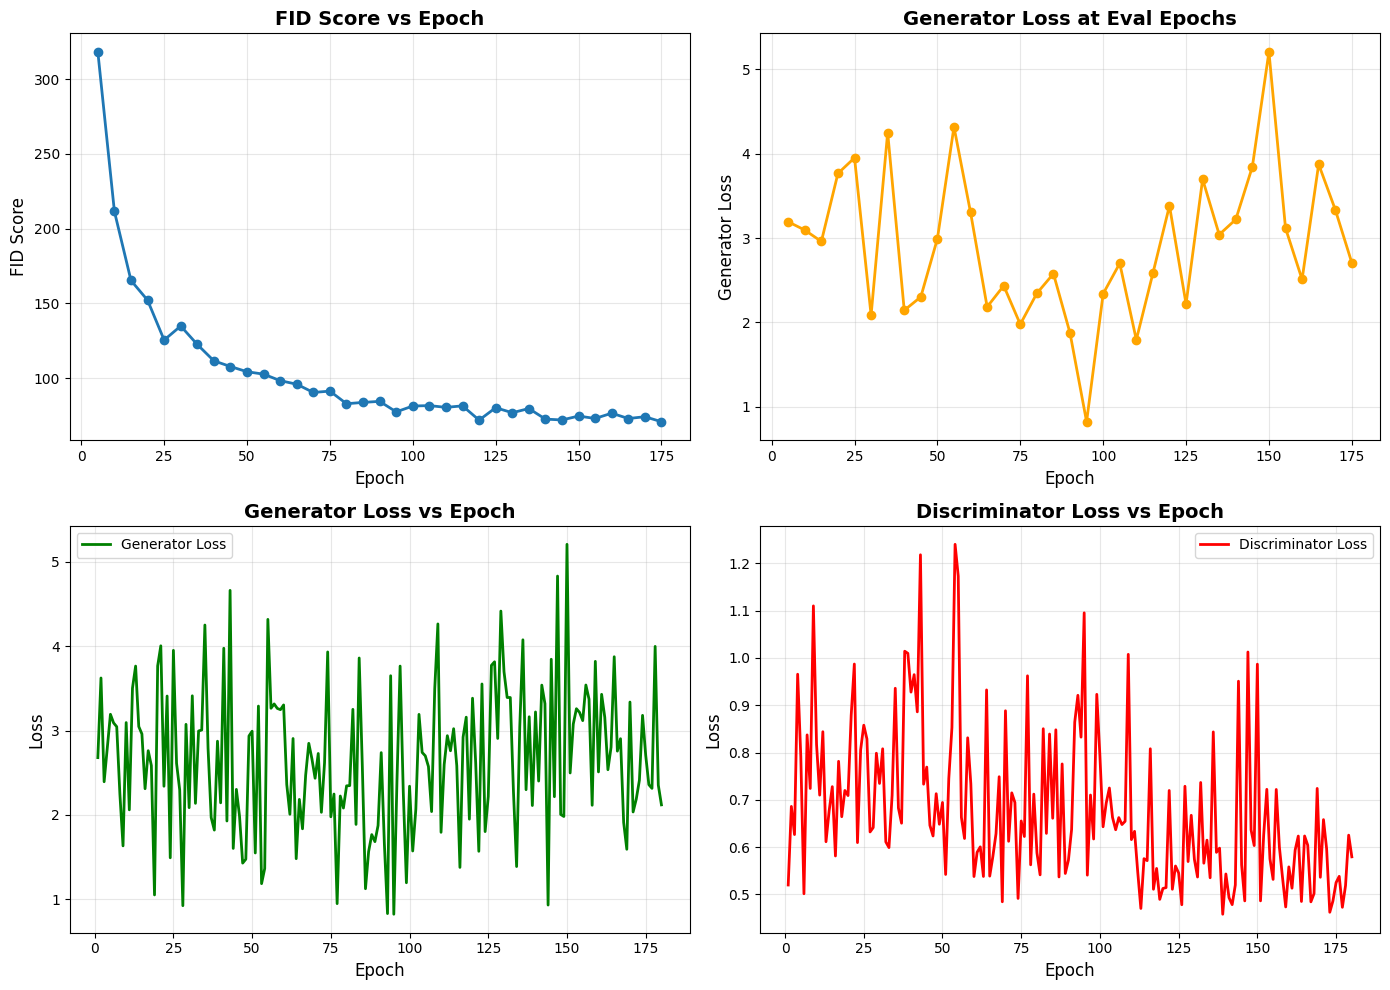


METRICS SUMMARY
 epoch        FID   G_loss   D_loss
     5 318.296356 3.192790 0.791117
    10 211.544418 3.094672 0.817225
    15 165.339706 2.959588 0.727836
    20 152.162781 3.765536 0.709026
    25 125.494942 3.950187 0.857800
    30 134.868515 2.087034 0.734641
    35 122.520416 4.249907 0.935904
    40 111.579292 2.144176 0.927826
    45 107.784195 2.303335 0.769246
    50 104.301315 2.992168 0.694409
    55 102.682083 4.316920 1.173143
    60  98.336487 3.303277 0.537786
    65  95.940742 2.184692 0.538640
    70  90.441574 2.435258 0.888334
    75  91.332642 1.978787 0.655256
    80  82.894547 2.345438 0.587804
    85  83.773575 2.578258 0.661014
    90  84.487907 1.875633 0.572665
    95  77.443932 0.824795 1.095402
   100  81.361496 2.340793 0.792238
   105  81.651031 2.700576 0.636737
   110  80.460869 1.795123 0.615877
   115  81.475922 2.582805 0.571379
   120  71.919815 3.383237 0.512511
   125  80.243118 2.219397 0.545199
   130  76.869728 3.696974 0.574197
   135  79.

In [4]:
# Visualize metrics against epochs
if metrics_history["epoch"]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # FID Score Plot
    axes[0, 0].plot(metrics_history["epoch"], metrics_history["FID"], marker='o', linewidth=2, markersize=6)
    axes[0, 0].set_xlabel("Epoch", fontsize=12)
    axes[0, 0].set_ylabel("FID Score", fontsize=12)
    axes[0, 0].set_title("FID Score vs Epoch", fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Generator Loss at Evaluation Epochs
    axes[0, 1].plot(metrics_history["epoch"], metrics_history["G_loss"], marker='o', color='orange', linewidth=2, markersize=6)
    axes[0, 1].set_xlabel("Epoch", fontsize=12)
    axes[0, 1].set_ylabel("Generator Loss", fontsize=12)
    axes[0, 1].set_title("Generator Loss at Eval Epochs", fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Generator Loss Plot
    axes[1, 0].plot(range(1, len(G_losses_final) + 1), G_losses_final, label='Generator Loss', linewidth=2, color='green')
    axes[1, 0].set_xlabel("Epoch", fontsize=12)
    axes[1, 0].set_ylabel("Loss", fontsize=12)
    axes[1, 0].set_title("Generator Loss vs Epoch", fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Discriminator Loss Plot
    axes[1, 1].plot(range(1, len(D_losses_final) + 1), D_losses_final, label='Discriminator Loss', linewidth=2, color='red')
    axes[1, 1].set_xlabel("Epoch", fontsize=12)
    axes[1, 1].set_ylabel("Loss", fontsize=12)
    axes[1, 1].set_title("Discriminator Loss vs Epoch", fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig("../outputs/gan_metrics_visualization.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print metrics summary
    print("\n" + "="*60)
    print("METRICS SUMMARY")
    print("="*60)
    metrics_df = pd.DataFrame(metrics_history)
    print(metrics_df.to_string(index=False))
    print("="*60)
else:
    print("No metrics recorded. Ensure evaluation was run during training.")

In [ ]:
# Load and inference from saved checkpoint
from src.models.generator import Generator

# Prefer model checkpoint dir first, then outputs path fallback
candidate_paths = [
    "../models/gan_checkpoints/gan_final.pth",
    "../outputs/final_generator.pth",
]

checkpoint_path = None
for p in candidate_paths:
    if os.path.exists(p):
        checkpoint_path = p
        break

if checkpoint_path is None:
    raise FileNotFoundError("No final GAN checkpoint found. Run final training cell first.")

print(f"Loading saved model from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device)
config_loaded = checkpoint["config"]

G_loaded = Generator(
    latent_dim=config_loaded["latent_dim"],
    channels=config_loaded["g_channels"],
    use_batchnorm=config_loaded["use_batchnorm"],
    activation=config_loaded["activation"]
).to(device)

G_loaded.load_state_dict(checkpoint["generator_state_dict"])

# Generate samples from loaded model
print("Generating samples from loaded model...")
samples = generate_samples(G_loaded, device, config_loaded["latent_dim"], n_samples=16)
show_images(samples, "Samples from Loaded Model")

# Evaluate loaded model
fid_loaded, is_loaded = evaluate_and_save(
    G_loaded, device,
    config_loaded["latent_dim"],
    "../outputs/loaded_model_samples.png",
    test_loader
)
print(f"Loaded Model - FID: {fid_loaded:.2f}, IS: {is_loaded:.2f}")